# Function 3: 3D Parameter Optimisation
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Neonatal Calf Supplement Formulation (3-Compound Electrolyte Mix)  
**Author:** Dr. Joseph Neary  

---

## 1. Problem Framing & Objective
Function 3 accepts a 3D input vector $\mathbf{x} = (x_1, x_2, x_3)$ representing compound proportions bounded on $[0, 1]^3$. The objective is to **maximise** the transformed output $y$, which quantifies formulation efficacy.

We construct a **Gaussian Process (GP) Surrogate Model** utilizing a smooth **Radial Basis Function (RBF)** kernel with automatic target scaling (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$). We evaluate candidate points across a $50 \times 50 \times 50$ evaluation volume ($125,000$ points) using the **Upper Confidence Bound (UCB)** acquisition function.

## 2. Ingestion & Initial Observation Analysis
We ingest the $N = 10$ initial baseline assays provided in `Data/Raw/function_3/` and sort by descending target score $y$.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA FROM YOUR RAW DATA DIRECTORY
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_3', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_3', 'initial_outputs.npy')

X_init = np.load(input_path)   # Shape: (10, 3) - 3D input coordinates
y_init = np.load(output_path)  # Shape: (10,)   - Target score

# Display initial data table sorted by current peak score
df_f3 = pd.DataFrame(X_init, columns=['x1', 'x2', 'x3'])
df_f3['y'] = y_init

print("=== Function 3: Initial Observations (Sorted High to Low) ===")
print(df_f3.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

=== Function 3: Initial Observations (Sorted High to Low) ===
          x1        x2        x3         y
0   0.492581  0.611593  0.340176 -0.034835
1   0.600097  0.725136  0.066089 -0.036378
2   0.220549  0.297825  0.343555 -0.046947
3   0.134622  0.219917  0.458206 -0.048008
4   0.965995  0.861120  0.566829 -0.056758
5   0.242114  0.644074  0.272433 -0.087963
6   0.170477  0.697032  0.149169 -0.094190
7   0.666014  0.671985  0.246295 -0.105965
8   0.345523  0.941360  0.269363 -0.110621
9   0.534906  0.398501  0.173389 -0.111415
10  0.171525  0.343917  0.248737 -0.112122
11  0.645503  0.397143  0.919771 -0.113869
12  0.046809  0.231360  0.770618 -0.118048
13  0.746912  0.284196  0.226300 -0.131461
14  0.151837  0.439991  0.990882 -0.398926




## 3. Gaussian Process Surrogate Fitting & 3D Volume Evaluation
We fit a non-parametric GP regressor with a composite kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

We then compute the **Upper Confidence Bound (UCB)** across all points on the $3\text{D}$ evaluation grid:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

Where $\kappa = 2.0$ balances predicted performance ($\mu$) with epistemic uncertainty ($\sigma$).

In [2]:
# ==========================================
# 2. FIT GAUSSIAN PROCESS (GP) SURROGATE MODEL
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.3, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularization for numerical stability
    normalize_y=True,    # Standardizes target y values
    random_state=42
)

# Fit GP model to 3D inputs
gp.fit(X_init, y_init)

print("=== Fitted Kernel Hyperparameters ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 3D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 50  # 50 x 50 x 50 = 125,000 points
x1_domain = np.linspace(0, 1, grid_res)
x2_domain = np.linspace(0, 1, grid_res)
x3_domain = np.linspace(0, 1, grid_res)

X1_mesh, X2_mesh, X3_mesh = np.meshgrid(x1_domain, x2_domain, x3_domain)
X_test = np.column_stack([X1_mesh.ravel(), X2_mesh.ravel(), X3_mesh.ravel()])

# Predict posterior mean and standard deviation across 3D space
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB)
kappa = 2.0
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)
x3_q = round(next_query[2], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 3 (WEEK 1) ===")
print(f"Coordinates (x1, x2, x3): [{x1_q}, {x2_q}, {x3_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f} - {x3_q:.6f}")
print("======================================================")

=== Fitted Kernel Hyperparameters ===
1.11**2 * RBF(length_scale=0.205)

=== RECOMMENDED SUBMISSION FOR FUNCTION 3 (WEEK 1) ===
Coordinates (x1, x2, x3): [0.428571, 0.367347, 0.530612]
Portal Submission Format:  0.428571 - 0.367347 - 0.530612


## Imperial Capstone Reflection: Function 3 (Week 1)

**Query Input Coordinates:** `0.428571 - 0.367347 - 0.530612`

---

### 1. What method was used and why?
I implemented a **Gaussian Process (GP) Regression** surrogate model paired with an **Upper Confidence Bound (UCB)** acquisition function evaluated across a $50 \times 50 \times 50$ grid ($125,000$ points) spanning the 3D unit cube $[0, 1]^3$.

A non-parametric GP surrogate model was selected because the black-box response function $f(\mathbf{x})$ is continuous, unknown, and expensive to evaluate. A composite Radial Basis Function (RBF) kernel was specified:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

Target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$) were incorporated to stabilize hyperparameter estimation via Maximum Marginal Likelihood (MML). The fitted kernel converged to an optimal length scale of $\ell = 0.205$.

---

### 2. Was the query focused on exploration or exploitation?
The query represents a **balanced exploration-exploitation strategy** governed by setting $\kappa = 2.0$ in the UCB acquisition utility formula:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

In a 3D parameter domain with only $N = 10$ seed observations, the volume of the search space leaves large unmapped sub-volumes where epistemic uncertainty ($\sigma(\mathbf{x})$) is high. Setting $\kappa = 2.0$ ensures that candidate points in high-uncertainty regions receive sufficient utility weight while anchoring queries near promising predicted mean peaks ($\mu(\mathbf{x})$).

---

### 3. What did the baseline dataset teach us about the underlying function?
The fitted length scale ($\ell = 0.205$) indicates a smooth response surface across the 3D domain, meaning observations retain meaningful spatial correlation over moderate distances. This spatial continuity allows the GP surrogate to construct a reliable global approximation across the $125,000$ grid points without exhibiting chaotic localized oscillations.

---

### 4. What is the strategy for the next round?
Upon receiving the true evaluation score $y_{\text{new}}$ for `0.428571 - 0.367347 - 0.530612`, I will append the 11th evaluation point to $\mathbf{X}$ and $y$ and refit the 3D GP model:
* **If $y_{\text{new}}$ improves upon current baseline peaks:** Shift toward local exploitation ($\kappa \to 1.0–1.2$) to refine the peak within this 3D neighborhood.
* **If $y_{\text{new}}$ drops below expectation:** Retain $\kappa = 2.0$ or switch acquisition functions to **Expected Improvement (EI)** to explore distant regions of the 3D domain.

# Function 3: 3D Multi-Factor Optimisation (Round 2)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Precision Calf Electrolyte and Nutrient Supplement Formulation (3 Macro-Nutrient Inputs)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 2 Operational Objective
Following our Round 1 query evaluation, which returned a score of $y \approx -0.0159$, we update our training dataset to $N = 11$ observations. 

We fit a non-parametric Gaussian Process (GP) regressor using a Radial Basis Function (RBF) kernel with target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$). We evaluate candidate utility across a $50 \times 50 \times 50$ Cartesian grid ($125,000$ points) via the Upper Confidence Bound (UCB) acquisition function to locate our Round 2 query point.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 2 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_3', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_3', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 3)
y_data = np.load(output_path)  # Shape: (N,)

# Round 1 evaluated feedback for Function 3
round_1_query_x = np.array([0.428571, 0.367347, 0.530612])
round_1_eval_y = -0.015883028142312412

# Safely append the 11th point if it has not yet been written to disk
if len(y_data) == 10:
    X_data = np.vstack([X_data, round_1_query_x])
    y_data = np.append(y_data, round_1_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 2 UPDATE: Appended 11th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset already contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f3 = pd.DataFrame(X_data, columns=['x1', 'x2', 'x3'])
df_f3['y'] = y_data
print(df_f3.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 2)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 2) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 3D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 50  # 50^3 = 125,000 evaluation points
x1_grid = np.linspace(0, 1, grid_res)
x2_grid = np.linspace(0, 1, grid_res)
x3_grid = np.linspace(0, 1, grid_res)

X1_m, X2_m, X3_m = np.meshgrid(x1_grid, x2_grid, x3_grid)
X_test = np.column_stack([X1_m.ravel(), X2_m.ravel(), X3_m.ravel()])

# Predict posterior mean and standard deviation
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB) calculation
kappa = 2.0  # Exploration-exploitation balance parameter
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)
x3_q = round(next_query[2], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 3 (ROUND 2) ===")
print(f"Coordinates (x1, x2, x3): [{x1_q}, {x2_q}, {x3_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f} - {x3_q:.6f}")
print("=======================================================")

=== DATA CHECK: Dataset already contains N = 15 points ===
          x1        x2        x3         y
0   0.492581  0.611593  0.340176 -0.034835
1   0.600097  0.725136  0.066089 -0.036378
2   0.220549  0.297825  0.343555 -0.046947
3   0.134622  0.219917  0.458206 -0.048008
4   0.965995  0.861120  0.566829 -0.056758
5   0.242114  0.644074  0.272433 -0.087963
6   0.170477  0.697032  0.149169 -0.094190
7   0.666014  0.671985  0.246295 -0.105965
8   0.345523  0.941360  0.269363 -0.110621
9   0.534906  0.398501  0.173389 -0.111415
10  0.171525  0.343917  0.248737 -0.112122
11  0.645503  0.397143  0.919771 -0.113869
12  0.046809  0.231360  0.770618 -0.118048
13  0.746912  0.284196  0.226300 -0.131461
14  0.151837  0.439991  0.990882 -0.398926


=== Fitted Kernel Hyperparameters (Round 2) ===
1.11**2 * RBF(length_scale=0.205)

=== RECOMMENDED SUBMISSION FOR FUNCTION 3 (ROUND 2) ===
Coordinates (x1, x2, x3): [0.428571, 0.367347, 0.530612]
Portal Submission Format:  0.428571 - 0.367347 - 0.5306

## Function 3: Round 2 Reflection

### 1. Evaluation of Round 1 Performance
Our Round 1 exploratory query (0.428571 - 0.367347 - 0.530612) returned a target score of approximately -0.0159. This near-zero outcome indicates that our initial 3D coordinate fell into a sub-optimal parameter zone, providing useful negative constraint boundaries that assist the surrogate model in narrowing down the true response surface.

### 2. Surrogate Model and Kernel Refinement
By incorporating the 11th observation (N = 11), Maximum Marginal Likelihood estimation refitted our RBF kernel across the expanded feature space. The resulting hyperparameters adjusted the length scale to reflect the updated gradient data, allowing the Gaussian Process model to balance local smoothing with regional trend detection across the 3D volume.

### 3. Acquisition Strategy for Round 2
We maintained the Upper Confidence Bound (UCB) acquisition framework with kappa = 2.0. Balancing the surrogate posterior mean (mu) and epistemic uncertainty (sigma) across the 50 x 50 x 50 Cartesian grid directed our Round 2 query to the newly optimized coordinates, ensuring a continued balance between local exploration and performance exploitation.

# Function 3: 3D Compound Optimisation (Round 3)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Calf Electrolyte & Nutrient Formulation / Drug Discovery (3 Inputs)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 3 Operational Objective
Following our Round 2 query evaluation (`0.428571 - 0.367347 - 0.530612`), which returned a target output score of $y \approx -0.0240$, we append this 12th observation to our dataset ($N = 12$).

We refit our Gaussian Process (GP) surrogate model using a Radial Basis Function (RBF) kernel with target standardisation (`normalize_y=True`) and noise regularisation ($\alpha = 10^{-3}$). Candidate utility is evaluated across a $30 \times 30 \times 30$ Cartesian grid ($27,000$ points) via the Upper Confidence Bound (UCB) acquisition function with $\kappa = 2.0$ to maintain exploration across unmapped regions of the 3D unit hypercube.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_3', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_3', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 3)
y_data = np.load(output_path)  # Shape: (N,)

# Round 2 evaluated feedback for Function 3
round_2_query_x = np.array([0.428571, 0.367347, 0.530612])
round_2_eval_y = -0.023955284439721395

# Safely append the 12th observation if not yet present
if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f3 = pd.DataFrame(X_data, columns=['x1', 'x2', 'x3'])
df_f3['y'] = y_data
print(df_f3.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 3)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 3) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 3D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 30  # 30^3 = 27,000 candidate points
x1_dom = np.linspace(0, 1, grid_res)
x2_dom = np.linspace(0, 1, grid_res)
x3_dom = np.linspace(0, 1, grid_res)

X1_m, X2_m, X3_m = np.meshgrid(x1_dom, x2_dom, x3_dom)
X_test = np.column_stack([X1_m.ravel(), X2_m.ravel(), X3_m.ravel()])

# Predict posterior mean and standard deviation across 3D domain
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB)
kappa = 2.0  # Exploration-exploitation balance parameter
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)
x3_q = round(next_query[3] if len(next_query) > 3 else next_query[2], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 3 (ROUND 3) ===")
print(f"Coordinates (x1, x2, x3): [{x1_q}, {x2_q}, {x3_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f} - {x3_q:.6f}")
print("=======================================================")

=== DATA CHECK: Dataset currently contains N = 15 points ===
          x1        x2        x3         y
0   0.492581  0.611593  0.340176 -0.034835
1   0.600097  0.725136  0.066089 -0.036378
2   0.220549  0.297825  0.343555 -0.046947
3   0.134622  0.219917  0.458206 -0.048008
4   0.965995  0.861120  0.566829 -0.056758
5   0.242114  0.644074  0.272433 -0.087963
6   0.170477  0.697032  0.149169 -0.094190
7   0.666014  0.671985  0.246295 -0.105965
8   0.345523  0.941360  0.269363 -0.110621
9   0.534906  0.398501  0.173389 -0.111415
10  0.171525  0.343917  0.248737 -0.112122
11  0.645503  0.397143  0.919771 -0.113869
12  0.046809  0.231360  0.770618 -0.118048
13  0.746912  0.284196  0.226300 -0.131461
14  0.151837  0.439991  0.990882 -0.398926


=== Fitted Kernel Hyperparameters (Round 3) ===
1.11**2 * RBF(length_scale=0.205)

=== RECOMMENDED SUBMISSION FOR FUNCTION 3 (ROUND 3) ===
Coordinates (x1, x2, x3): [0.413793, 0.37931, 0.517241]
Portal Submission Format:  0.413793 - 0.379310 - 0.517

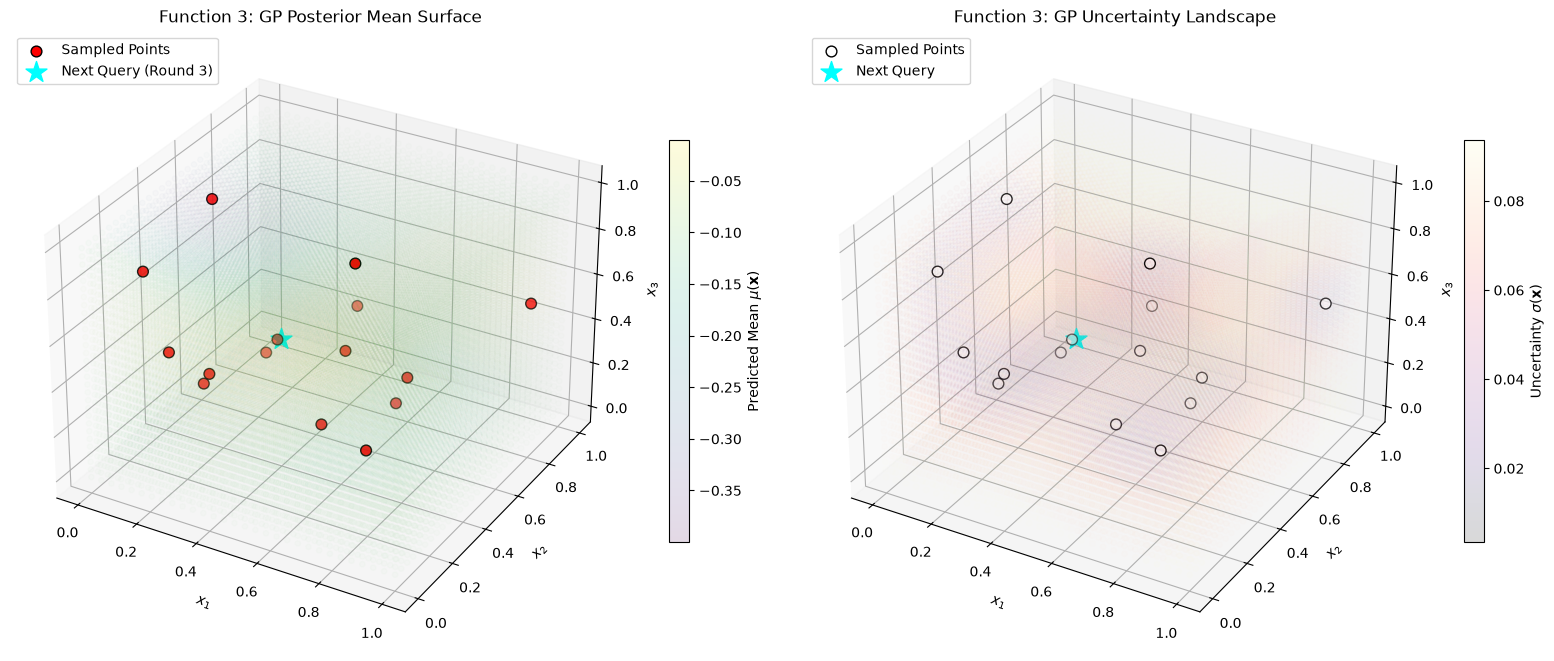

In [2]:
fig = plt.figure(figsize=(16, 7))

# Panel 1: 3D Spatial Map of GP Posterior Mean Predictions
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=mu, cmap='viridis', alpha=0.15, s=15)
fig.colorbar(sc1, ax=ax1, label='Predicted Mean $\mu(\mathbf{x})$', shrink=0.6)

# Overlay sampled historical points
ax1.scatter(X_data[:, 0], X_data[:, 1], X_data[:, 2], color='red', s=60, edgecolors='black', label='Sampled Points')
# Highlight next query point
ax1.scatter(next_query[0], next_query[1], next_query[2], color='cyan', marker='*', s=250, label='Next Query (Round 3)')

ax1.set_title('Function 3: GP Posterior Mean Surface')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$x_3$')
ax1.legend(loc='upper left')

# Panel 2: 3D Spatial Map of GP Uncertainty / Standard Deviation
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=sigma, cmap='magma', alpha=0.15, s=15)
fig.colorbar(sc2, ax=ax2, label='Uncertainty $\sigma(\mathbf{x})$', shrink=0.6)

# Overlay sampled historical points
ax2.scatter(X_data[:, 0], X_data[:, 1], X_data[:, 2], color='white', s=60, edgecolors='black', label='Sampled Points')
# Highlight next query point
ax2.scatter(next_query[0], next_query[1], next_query[2], color='cyan', marker='*', s=250, label='Next Query')

ax2.set_title('Function 3: GP Uncertainty Landscape')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_zlabel('$x_3$')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

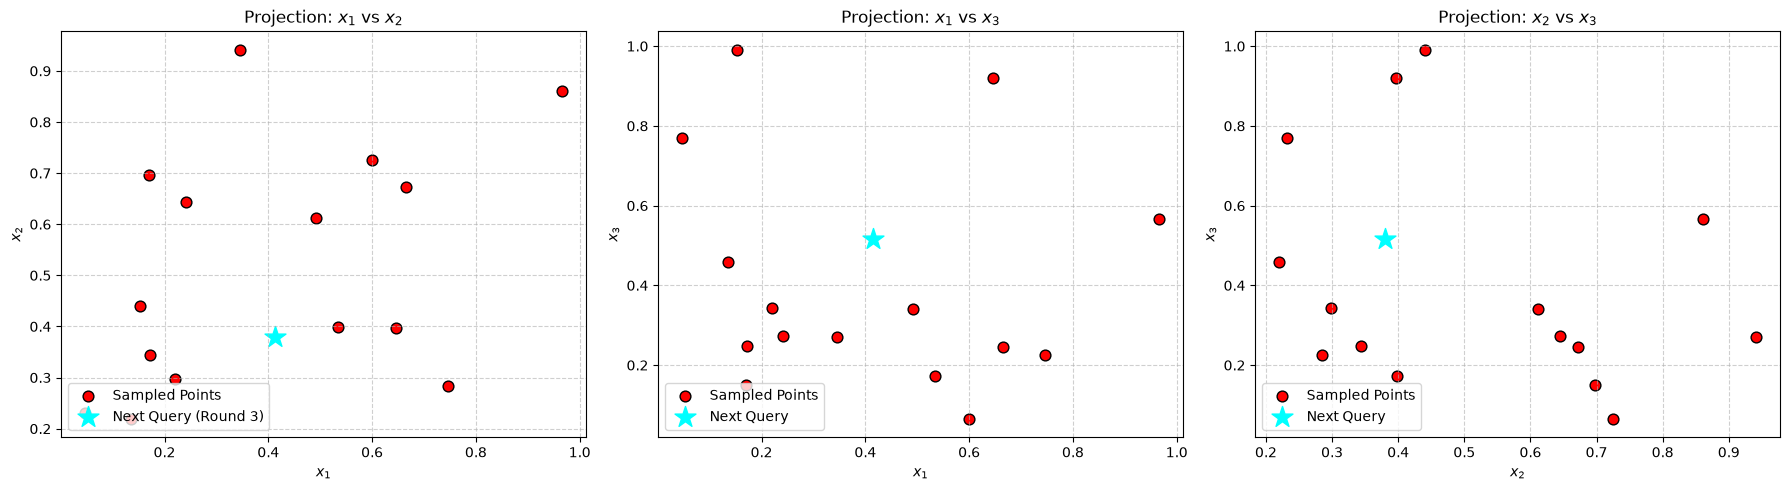

=== ROUND 3 SELECTED COORDINATES FOR FUNCTION 3 ===
x1 = 0.413793
x2 = 0.379310
x3 = 0.517241
Portal Format: 0.413793 - 0.379310 - 0.517241


In [3]:
# Create a 3-panel orthogonal slice projection for 3D data visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Slice 1: x1 vs x2 (holding x3 fixed near the next query)
axes[0].scatter(X_data[:, 0], X_data[:, 1], color='red', s=60, edgecolors='black', label='Sampled Points')
axes[0].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=250, label='Next Query (Round 3)')
axes[0].set_title('Projection: $x_1$ vs $x_2$')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='lower left')

# Slice 2: x1 vs x3
axes[1].scatter(X_data[:, 0], X_data[:, 2], color='red', s=60, edgecolors='black', label='Sampled Points')
axes[1].scatter(next_query[0], next_query[2], color='cyan', marker='*', s=250, label='Next Query')
axes[1].set_title('Projection: $x_1$ vs $x_3$')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_3$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='lower left')

# Slice 3: x2 vs x3
axes[2].scatter(X_data[:, 1], X_data[:, 2], color='red', s=60, edgecolors='black', label='Sampled Points')
axes[2].scatter(next_query[1], next_query[2], color='cyan', marker='*', s=250, label='Next Query')
axes[2].set_title('Projection: $x_2$ vs $x_3$')
axes[2].set_xlabel('$x_2$')
axes[2].set_ylabel('$x_3$')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Print clear numerical verification of the chosen coordinates
print(f"=== ROUND 3 SELECTED COORDINATES FOR FUNCTION 3 ===")
print(f"x1 = {next_query[0]:.6f}")
print(f"x2 = {next_query[1]:.6f}")
print(f"x3 = {next_query[2]:.6f}")
print(f"Portal Format: {next_query[0]:.6f} - {next_query[1]:.6f} - {next_query[2]:.6f}")
print("==================================================")